# 🔬 Training Baseline: EfficientNet-B3 + GRU **TANPA AUGMENTASI**

Notebook ini adalah **eksperimen pembanding (baseline)** yang diminta oleh Pembimbing 2.

| Komponen | Baseline (Notebook Ini) | Model Final (V5) |
|---|---|---|
| Data Train | **4.392 citra asli** | 52.704 citra |
| Validasi | 566 citra | 566 citra |
| Test | 504 citra | 504 citra |
| Noise Angin/Hujan | ❌ Tidak | ✅ Ya |
| SpecAugment | ❌ Tidak | ✅ Ya |
| Arsitektur | EfficientNet-B3 + GRU | EfficientNet-B3 + GRU |
| Hyperparameter | **Identik** | Identik |
| Random Seed | **42** | 42 |

**Preprocessing tetap sama:** Mono → Resampling 32kHz → Normalisasi → Segmentasi 5 dtk → Salient Filtering → Bandpass → Denoising → Log-Mel Spectrogram.

**Yang dihilangkan:** Noise angin/hujan, Frequency Masking, Time Masking, Gabungan masking.

In [ ]:
# ============================================================
# SEL 1: IMPORT LIBRARY & MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
import zipfile, os, random
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB3
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

drive.mount('/content/drive')
print('GPU aktif:', tf.config.list_physical_devices('GPU'))
print('TensorFlow:', tf.__version__)

# --- SEED GLOBAL (IDENTIK dengan V5) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'Random seed: {SEED}')

Mounted at /content/drive
GPU aktif: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0
Random seed: 42


In [ ]:
# ============================================================
# SEL 2: EKSTRAK DATASET BASELINE (TANPA AUGMENTASI)
# ============================================================
zip_path = '/content/drive/MyDrive/Skripsi/dataset_baseline.zip'
extract_path = '/content'  # Diubah agar tidak double folder

if not os.path.exists('/content/dataset_baseline/dataset_spectrograms/train'):
    print('Mengekstrak dataset BASELINE (tanpa augmentasi)...')
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            fixed_name = member.replace('\\', '/')
            target_path = os.path.join(extract_path, fixed_name)
            if fixed_name.endswith('/'):
                os.makedirs(target_path, exist_ok=True)
            else:
                os.makedirs(os.path.dirname(target_path), exist_ok=True)
                with zip_ref.open(member) as src, open(target_path, 'wb') as dst:
                    dst.write(src.read())
    print('Ekstrak selesai!')
else:
    print('Dataset baseline sudah terekstrak.')

Mengekstrak dataset BASELINE (tanpa augmentasi)...
Ekstrak selesai!


In [ ]:
# ============================================================
# SEL 3: VERIFIKASI JUMLAH DATA BASELINE
# Harus menampilkan: Train=4392, Val=566, Test=504
# ============================================================
for split in ['train', 'val', 'test']:
    p = f'/content/dataset_baseline/dataset_spectrograms/{split}'
    if os.path.exists(p):
        total = sum(len(os.listdir(os.path.join(p, d)))
                    for d in os.listdir(p)
                    if os.path.isdir(os.path.join(p, d)))
        print(f'Total gambar {split}: {total}')
        # Detail per spesies
        for d in sorted(os.listdir(p)):
            dp = os.path.join(p, d)
            if os.path.isdir(dp):
                print(f'  - {d}: {len(os.listdir(dp))}')
    else:
        print(f'[ERROR] Folder {p} tidak ditemukan!')

print('\n--- VALIDASI ---')
print('Jika Train BUKAN 4.392, dataset salah! Pastikan tidak ada file augmentasi.')

Total gambar train: 4392
  - Geopelia striata: 900
  - Passer montanus: 866
  - Pycnonotus aurigaster: 880
  - Pycnonotus goiavier: 854
  - Streptopelia chinensis: 892
Total gambar val: 566
  - Geopelia striata: 111
  - Passer montanus: 105
  - Pycnonotus aurigaster: 108
  - Pycnonotus goiavier: 121
  - Streptopelia chinensis: 121
Total gambar test: 504
  - Geopelia striata: 105
  - Passer montanus: 98
  - Pycnonotus aurigaster: 107
  - Pycnonotus goiavier: 101
  - Streptopelia chinensis: 93

--- VALIDASI ---
Jika Train BUKAN 4.392, dataset salah! Pastikan tidak ada file augmentasi.


In [ ]:
# ============================================================
# SEL 4: MEMBACA DATASET
# Parameter IDENTIK dengan V5
# ============================================================
BATCH_SIZE = 32
IMG_SIZE = (300, 300)

train_dir = '/content/dataset_baseline/dataset_spectrograms/train'
val_dir   = '/content/dataset_baseline/dataset_spectrograms/val'
test_dir  = '/content/dataset_baseline/dataset_spectrograms/test'

print('[1/3] Membaca Data Train (BASELINE - 4.392 citra):')
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical', seed=SEED
)
print('[2/3] Membaca Data Validasi (566 citra):')
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, shuffle=False, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical'
)
print('[3/3] Membaca Data Test (504 citra):')
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, shuffle=False, batch_size=BATCH_SIZE,
    image_size=IMG_SIZE, label_mode='categorical'
)
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'\nKelas: {class_names}')
print(f'Jumlah kelas: {num_classes}')

[1/3] Membaca Data Train (BASELINE - 4.392 citra):
Found 4392 files belonging to 5 classes.
[2/3] Membaca Data Validasi (566 citra):
Found 566 files belonging to 5 classes.
[3/3] Membaca Data Test (504 citra):
Found 504 files belonging to 5 classes.

Kelas: ['Geopelia striata', 'Passer montanus', 'Pycnonotus aurigaster', 'Pycnonotus goiavier', 'Streptopelia chinensis']
Jumlah kelas: 5


In [ ]:
# ============================================================
# SEL 5: MEMBANGUN ARSITEKTUR (IDENTIK DENGAN V5)
# EfficientNet-B3 + GRU
# Input: 300x300x3 (RGB Image)
# ============================================================
def build_model(num_classes):
    inputs = layers.Input(shape=IMG_SIZE + (3,))

    base_model = EfficientNetB3(
        include_top=False,
        input_tensor=inputs,
        weights='imagenet'
    )
    base_model.trainable = False

    feat = base_model.output
    x = layers.Reshape((100, 1536))(feat)  # 10x10x1536 → 100 timesteps
    x = layers.GRU(256, return_sequences=False, name='gru_layer')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4, name='top_dropout')(x)  # IDENTIK: 0.4
    outputs = layers.Dense(
        num_classes, activation='softmax', name='pred',
        kernel_regularizer=tf.keras.regularizers.l2(1e-4)  # IDENTIK: L2 1e-4
    )(x)

    model = models.Model(inputs, outputs)
    return model

model = build_model(num_classes)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 300, 300,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 300, 300,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 301, 301,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 150, 150,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 150, 150,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 150, 150,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 150, 150,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 150, 150,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 150, 150,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 150, 150,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 150, 150,  │        960 │ block1a_se_excit

 Total params: 12,163,636 (46.40 MB)

 Trainable params: 1,379,589 (5.26 MB)

 Non-trainable params: 10,784,047 (41.14 MB)

In [ ]:
# ============================================================
# SEL 6: FASE 1 - TRAINING KEPALA MODEL (IDENTIK DENGAN V5)
# Focal Loss + Auto Checkpoint ke Google Drive
# ============================================================
import os
os.makedirs('/content/drive/MyDrive/Skripsi/Backup_Baseline', exist_ok=True)

# --- AUTO-RESUME: Skip Fase 1 jika checkpoint sudah ada ---
FASE1_CKPT = '/content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase1_baseline.keras'

if os.path.exists(FASE1_CKPT):
    print('Checkpoint Fase 1 BASELINE ditemukan! Memuat model dari Drive...')
    model = tf.keras.models.load_model(FASE1_CKPT)
    print('Model Fase 1 dimuat. SKIP training Fase 1.')
    class DummyHistory1:
        history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    history_p1 = DummyHistory1()
else:
    steps_per_epoch = len(train_dataset)

    # IDENTIK: Cosine Decay 1e-3 → 1e-6, 30 epochs
    cosine_lr_p1 = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=1e-3,
        decay_steps=steps_per_epoch * 30,
        alpha=1e-6
    )

    # IDENTIK: Focal Loss + Label Smoothing 0.05
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr_p1),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=0.25, gamma=2.0, label_smoothing=0.05
        ),
        metrics=['accuracy']
    )

    # IDENTIK: Early Stopping patience=8, monitor val_accuracy
    early_stopping_p1 = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    )

    checkpoint_p1 = callbacks.ModelCheckpoint(
        FASE1_CKPT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    )

    print('FASE 1 BASELINE: MELATIH KEPALA MODEL (4.392 citra, TANPA augmentasi)...')
    history_p1 = model.fit(
        train_dataset, epochs=30,
        validation_data=val_dataset,
        callbacks=[early_stopping_p1, checkpoint_p1]
    )
    print('Fase 1 BASELINE selesai!')

FASE 1 BASELINE: MELATIH KEPALA MODEL (4.392 citra, TANPA augmentasi)...
Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.5080 - loss: 0.3120
Epoch 1: val_accuracy improved from None to 0.55124, saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase1_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase1_baseline.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 347ms/step - accuracy: 0.5822 - loss: 0.2398 - val_accuracy: 0.5512 - val_loss: 0.1642
Epoch 2/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.6971 - loss: 0.1511
Epoch 2: val_accuracy improved from 0.55124 to 0.64664, saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase1_baseline.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase1_baseline.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 41s 294ms/step - accuracy: 0.7056 - loss: 0.1460 - val_accuracy: 0.6466 - val_loss: 0.1585
Epoch 3/

In [ ]:
# ============================================================
# SEL 7: FASE 2 - FINE-TUNING (IDENTIK DENGAN V5)
# ============================================================
FASE2_CKPT = '/content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase2_baseline.keras'

if os.path.exists(FASE2_CKPT):
    print('Checkpoint Fase 2 BASELINE ditemukan! Memuat model dari Drive...')
    model = tf.keras.models.load_model(FASE2_CKPT)
    print('Model Fase 2 dimuat. SKIP training Fase 2.')
    class DummyHistory2:
        history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
    history_p2 = DummyHistory2()
else:
    # IDENTIK: Unfreeze lapisan 100+ dan kunci semua BatchNorm
    model.trainable = True
    for layer in model.layers[:100]:
        layer.trainable = False
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    steps_per_epoch = len(train_dataset)

    # IDENTIK: Cosine Decay 5e-5 → 1e-7, 50 epochs
    cosine_lr_p2 = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=5e-5,
        decay_steps=steps_per_epoch * 50,
        alpha=1e-7
    )

    # IDENTIK: Focal Loss + Label Smoothing 0.05
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr_p2),
        loss=tf.keras.losses.CategoricalFocalCrossentropy(
            alpha=0.25, gamma=2.0, label_smoothing=0.05
        ),
        metrics=['accuracy']
    )

    # IDENTIK: Early Stopping patience=10, monitor val_accuracy
    early_stopping_p2 = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10,
        restore_best_weights=True, verbose=1
    )

    checkpoint_p2 = callbacks.ModelCheckpoint(
        FASE2_CKPT, monitor='val_accuracy',
        save_best_only=True, verbose=1
    )

    print('FASE 2 BASELINE: FINE-TUNING (4.392 citra, TANPA augmentasi)...')
    history_p2 = model.fit(
        train_dataset, epochs=50,
        validation_data=val_dataset,
        callbacks=[early_stopping_p2, checkpoint_p2]
    )
    print('Fase 2 BASELINE selesai!')

FASE 2 BASELINE: FINE-TUNING (4.392 citra, TANPA augmentasi)...
Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8909 - loss: 0.0719
Epoch 1: val_accuracy improved from None to 0.76855, saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase2_baseline.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Skripsi/Backup_Baseline/best_fase2_baseline.keras
138/138 ━━━━━━━━━━━━━━━━━━━━ 65s 345ms/step - accuracy: 0.8971 - loss: 0.0677 - val_accuracy: 0.7686 - val_loss: 0.1182
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.8956 - loss: 0.0669
Epoch 2: val_accuracy did not improve from 0.76855
138/138 ━━━━━━━━━━━━━━━━━━━━ 41s 299ms/step - accuracy: 0.9021 - loss: 0.0650 - val_accuracy: 0.7668 - val_loss: 0.1161
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9092 - loss: 0.0613
Epoch 3: val_accuracy did not improve from 0.76855
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 293ms/step - accuracy: 0.9151 - loss: 0.0612 - 

EVALUASI FINAL MODEL BASELINE (TANPA AUGMENTASI)
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.7738 - loss: 0.0990

AKURASI FINAL BASELINE : 77.38%
Loss Final Baseline    : 0.0990


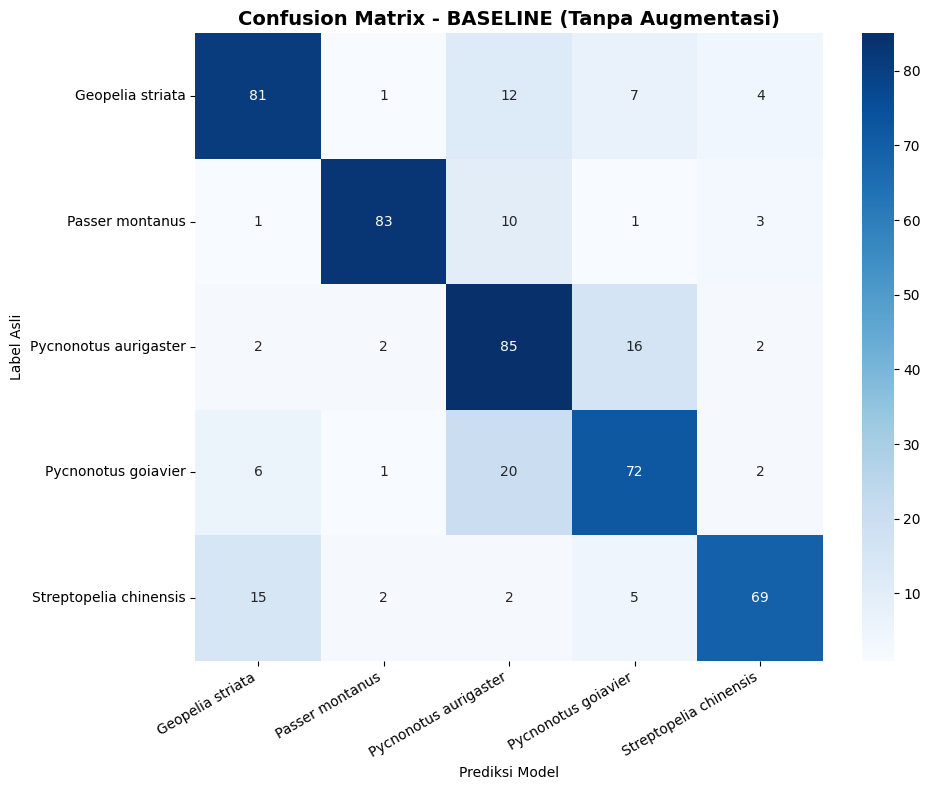

Confusion Matrix disimpan: /content/drive/MyDrive/Skripsi/Backup_Baseline/confusion_matrix_baseline.png

Classification Report BASELINE:
                        precision    recall  f1-score   support

      Geopelia striata       0.77      0.77      0.77       105
       Passer montanus       0.93      0.85      0.89        98
 Pycnonotus aurigaster       0.66      0.79      0.72       107
   Pycnonotus goiavier       0.71      0.71      0.71       101
Streptopelia chinensis       0.86      0.74      0.80        93

              accuracy                           0.77       504
             macro avg       0.79      0.77      0.78       504
          weighted avg       0.78      0.77      0.78       504

Report disimpan ke: /content/drive/MyDrive/Skripsi/Backup_Baseline/classification_report_baseline.txt


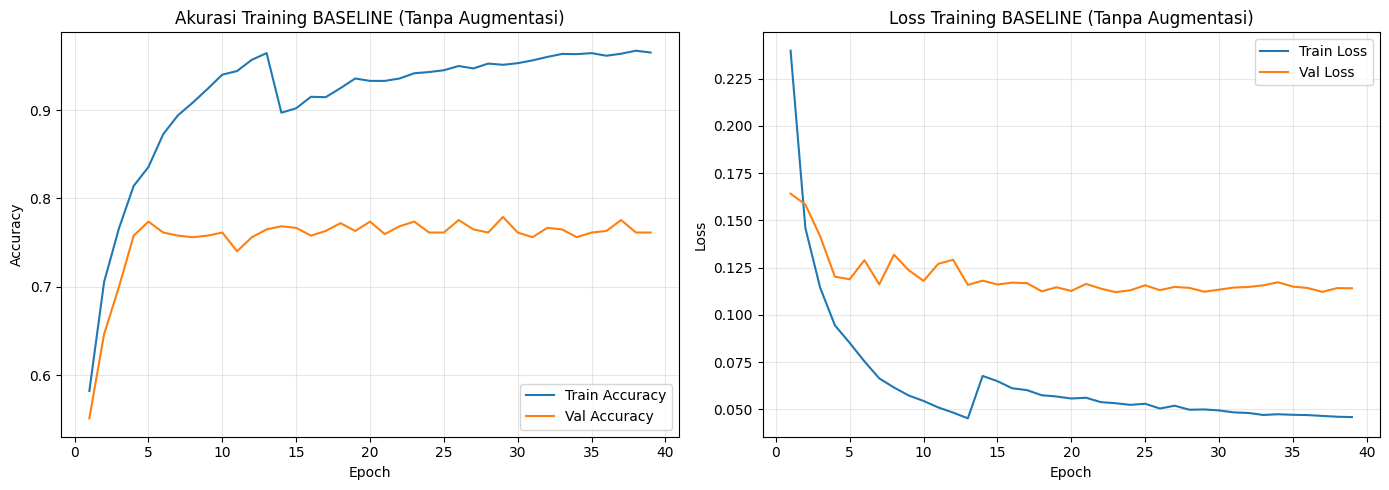

Grafik disimpan: /content/drive/MyDrive/Skripsi/Backup_Baseline/training_curves_baseline.png

Model BASELINE final disimpan: /content/drive/MyDrive/Skripsi/Backup_Baseline/model_baseline_final.keras


In [ ]:
# ============================================================
# SEL 8: EVALUASI LENGKAP + SIMPAN SEMUA HASIL KE DRIVE
# ============================================================
SAVE_DIR = '/content/drive/MyDrive/Skripsi/Backup_Baseline'

# --- A. Akurasi & Loss Final ---
print('=' * 60)
print('EVALUASI FINAL MODEL BASELINE (TANPA AUGMENTASI)')
print('=' * 60)
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f'\nAKURASI FINAL BASELINE : {test_acc*100:.2f}%')
print(f'Loss Final Baseline    : {test_loss:.4f}')

# --- B. Confusion Matrix ---
y_pred_probs = model.predict(test_dataset, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for _, y in test_dataset])

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title('Confusion Matrix - BASELINE (Tanpa Augmentasi)', fontsize=14, fontweight='bold')
ax.set_ylabel('Label Asli')
ax.set_xlabel('Prediksi Model')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
cm_path = f'{SAVE_DIR}/confusion_matrix_baseline.png'
plt.savefig(cm_path, dpi=300)
plt.show()
print(f'Confusion Matrix disimpan: {cm_path}')

# --- C. Classification Report ---
report = classification_report(y_true, y_pred, target_names=class_names)
print('\nClassification Report BASELINE:')
print(report)

# Simpan report ke file teks
with open(f'{SAVE_DIR}/classification_report_baseline.txt', 'w') as f:
    f.write(f'AKURASI FINAL BASELINE: {test_acc*100:.2f}%\n')
    f.write(f'Loss Final: {test_loss:.4f}\n\n')
    f.write(report)
print(f'Report disimpan ke: {SAVE_DIR}/classification_report_baseline.txt')

# --- D. Grafik Training ---
acc      = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc  = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss_h   = history_p1.history['loss']         + history_p2.history['loss']
val_loss = history_p1.history['val_loss']     + history_p2.history['val_loss']

if len(acc) > 0:
    ep_range = range(1, len(acc) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ep_range, acc, label='Train Accuracy')
    ax1.plot(ep_range, val_acc, label='Val Accuracy')
    ax1.set_title('Akurasi Training BASELINE (Tanpa Augmentasi)')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(ep_range, loss_h, label='Train Loss')
    ax2.plot(ep_range, val_loss, label='Val Loss')
    ax2.set_title('Loss Training BASELINE (Tanpa Augmentasi)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    graph_path = f'{SAVE_DIR}/training_curves_baseline.png'
    plt.savefig(graph_path, dpi=300)
    plt.show()
    print(f'Grafik disimpan: {graph_path}')
else:
    print('History kosong (model dimuat dari checkpoint). Grafik tidak dibuat.')

# --- E. Simpan Model Final ---
final_path = f'{SAVE_DIR}/model_baseline_final.keras'
model.save(final_path)
print(f'\nModel BASELINE final disimpan: {final_path}')

In [ ]:
# ============================================================
# SEL 9: TABEL PERBANDINGAN OTOMATIS
# ============================================================
print('=' * 70)
print('TABEL PERBANDINGAN: BASELINE vs MODEL AUGMENTASI (V5)')
print('=' * 70)
print(f'{"Metrik":<30} {"Baseline":<20} {"V5 (Augmentasi)":<20}')
print('-' * 70)
print(f'{"Data Train":<30} {"4.392 citra":<20} {"52.704 citra":<20}')
print(f'{"Noise Angin/Hujan":<30} {"Tidak":<20} {"Ya":<20}')
print(f'{"SpecAugment":<30} {"Tidak":<20} {"Ya":<20}')
print(f'{"Test Accuracy":<30} {f"{test_acc*100:.2f}%":<20} {"81.15%":<20}')
print(f'{"Test Loss":<30} {f"{test_loss:.4f}":<20} {"0.1070":<20}')
print('-' * 70)

# Hitung selisih
diff = test_acc * 100 - 81.15
if diff > 0:
    print(f'\n⚠️  Baseline LEBIH TINGGI {abs(diff):.2f}% dari V5.')
    print('    Kesimpulan: Augmentasi pada dataset ini justru MENURUNKAN performa.')
elif diff < 0:
    print(f'\n✅  V5 (Augmentasi) LEBIH TINGGI {abs(diff):.2f}% dari Baseline.')
    print('    Kesimpulan: Augmentasi MENINGKATKAN performa model.')
else:
    print(f'\n➡️  Kedua model memiliki akurasi SAMA.')
    print('    Kesimpulan: Augmentasi TIDAK memberikan perubahan berarti.')

print('\n--- Classification Report Baseline ---')
print(report)

TABEL PERBANDINGAN: BASELINE vs MODEL AUGMENTASI (V5)
Metrik                         Baseline             V5 (Augmentasi)     
----------------------------------------------------------------------
Data Train                     4.392 citra          52.704 citra        
Noise Angin/Hujan              Tidak                Ya                  
SpecAugment                    Tidak                Ya                  
Test Accuracy                  77.38%               81.15%              
Test Loss                      0.0990               0.1070              
----------------------------------------------------------------------

✅  V5 (Augmentasi) LEBIH TINGGI 3.77% dari Baseline.
    Kesimpulan: Augmentasi MENINGKATKAN performa model.

--- Classification Report Baseline ---
                        precision    recall  f1-score   support

      Geopelia striata       0.77      0.77      0.77       105
       Passer montanus       0.93      0.85      0.89        98
 Pycnonotus aurigaster 